# BurstCube Detector Response

BurstCube's detector response is a grid of Detector Response Matrices (DRMs),
one per HEALPix pixel (nside=16, RING ordering, 3072 pixels total) per
detector, in **spacecraft** coordinates -- not one response per source
position computed on the fly. This notebook covers the grid, downloading only
the pixels actually needed for one direction, interpolating a DRM, plotting
it and the effective area, folding a spectrum, and comparing the four
detectors at one location.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import healpy as hp

from gdt.core.plot.drm import ResponsePlot, PhotonEffectiveArea, ChannelEffectiveArea
from gdt.core.spectra.functions import PowerLaw

from gdt.missions.burstcube.response import (BurstCubeResponseGrid, BurstCubeRspFinder,
                                             NSIDE, NUM_PIXELS)
%matplotlib inline

print(f'grid: nside={NSIDE}, {NUM_PIXELS} pixels total')

grid: nside=16, 3072 pixels total


## The HEALPix grid, and downloading only what's needed

Full grid is ~1 GB across all 4 detectors; downloading it all just to look at
one direction would be wasteful. `BurstCubeRspFinder` figures out which
pixels a direction needs (4, for the default bilinear interpolation) and
fetches only those.

In [2]:
AZ, ZEN = 45.0, 30.0  # an arbitrary spacecraft-frame direction, in degrees

finder = BurstCubeRspFinder()
needed = finder.needed_pixels(az=AZ, zen=ZEN, interp=True)
print(f'direction (az={AZ}, zen={ZEN}) needs pixels {needed} (out of {NUM_PIXELS})')

_, weights = hp.get_interp_weights(NSIDE, np.radians(ZEN), np.radians(AZ))
print(f'interpolation weights: {weights} (sum = {weights.sum():.10f})')

direction (az=45.0, zen=30.0) needs pixels [184, 185, 225, 226] (out of 3072)
interpolation weights: [0.42842653 0.42842653 0.14314694 0.        ] (sum = 1.0000000000)


## Interpolating a DRM for a source position

`BurstCubeResponseGrid.get_drm()` is the primary entry point: give it a
detector and either `(az, zen)`, a HEALPix `pix`, or a sky position (which
needs a frame carrying attitude -- see below). It downloads (or reuses a
cached copy of) only the pixels it needs, lazily, with an LRU cache, and
never holds the whole grid in memory.

In [3]:
grid = BurstCubeResponseGrid(detectors='CS0')
drm = grid.get_drm('CS0', az=AZ, zen=ZEN, interp=True)
print(drm)
print(f'{drm.num_ebins} photon bins, {drm.num_chans} channels (native, not yet regrouped to CBD)')

<BurstCubeRsp: 
 time range (None, None);
 256 energy bins; 64 channels>
256 photon bins, 64 channels (native, not yet regrouped to CBD)


## Plotting the DRM and effective area

/usr/local/lib/python3.11/dist-packages/gdt/core/plot/drm.py:109: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  self._ax.set_ylim(*drm.ebounds.range)


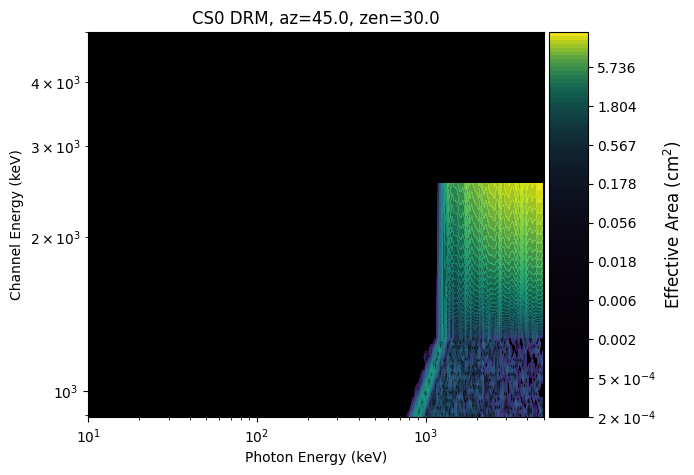

In [4]:
fig, ax = plt.subplots(figsize=(7, 5))
rplot = ResponsePlot(drm=drm.drm, ax=ax)
ax.set_title(f'CS0 DRM, az={AZ}, zen={ZEN}')
plt.show()

/usr/local/lib/python3.11/dist-packages/gdt/core/plot/drm.py:256: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  self._ax.set_xlim(xrange)


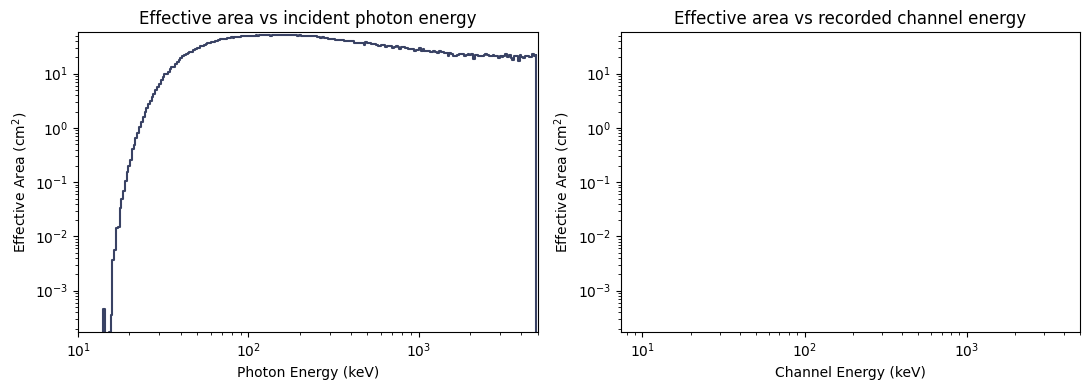

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
PhotonEffectiveArea(drm=drm.drm, ax=axes[0])
axes[0].set_title('Effective area vs incident photon energy')
ChannelEffectiveArea(drm=drm.drm, ax=axes[1])
axes[1].set_title('Effective area vs recorded channel energy')
fig.tight_layout()
plt.show()

## Folding a spectrum

Folding a photon model through the DRM gives the count spectrum that model
would produce in this detector, for this direction.

folded 64-channel count spectrum total: 109.6887 counts/s (for a 1 s exposure)


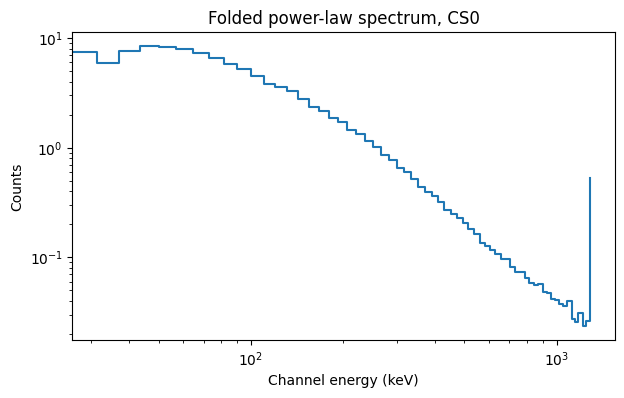

In [6]:
pl = PowerLaw()
folded = drm.fold_spectrum(pl.fit_eval, (0.01, -2.0))
print(f'folded 64-channel count spectrum total: {folded.counts.sum():.4f} counts/s (for a 1 s exposure)')

fig, ax = plt.subplots(figsize=(7, 4))
ax.step(folded.lo_edges, folded.counts, where='post')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Channel energy (keV)')
ax.set_ylabel('Counts')
ax.set_title('Folded power-law spectrum, CS0')
plt.show()

## Regrouping to CBD's 16 channels

`to_cbd()` regroups the native 64 channels to CBD's 16 using the CALDB-
verified edge indices, and replaces the channel energies with CALDB's
per-detector `eb16` (the .rsp file's own internal EBOUNDS is an older,
rounded, detector-independent grid -- see the README caveats).

In [7]:
cbd_drm = drm.to_cbd()
print(f'{drm.num_chans} channels -> {cbd_drm.num_chans} channels')
print(f'CBD eb16 top channel: {cbd_drm.ebounds.low_edges()[-1]:.2f}-{cbd_drm.ebounds.high_edges()[-1]:.2f} keV')

folded_cbd = cbd_drm.fold_spectrum(pl.fit_eval, (0.01, -2.0))
print(f'folded total (regrouped): {folded_cbd.counts.sum():.4f} (native 64ch total: {folded.counts.sum():.4f})')

64 channels -> 16 channels
CBD eb16 top channel: 1298.79-1648.51 keV
folded total (regrouped): 109.6887 (native 64ch total: 109.6887)


## Comparing the four detectors at one location

Since BurstCube's four detectors point in different directions (each 45 deg
off the spacecraft zenith, 90 deg apart in azimuth -- see
`gdt.missions.burstcube.detectors`), the same spacecraft-frame direction
illuminates each one differently.

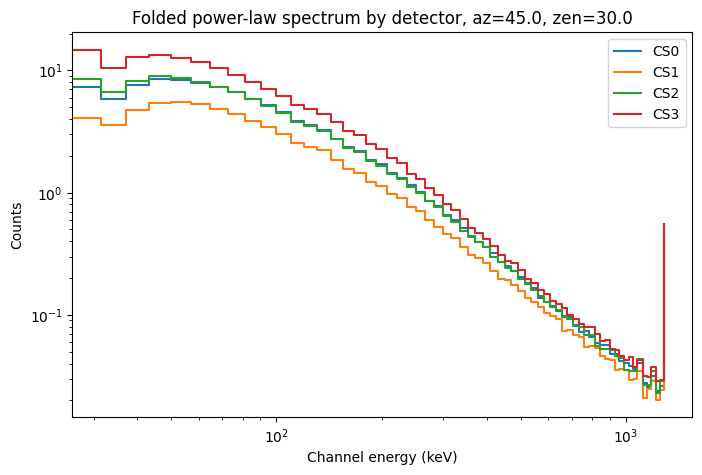

In [8]:
grid_all = BurstCubeResponseGrid()  # all 4 detectors by default
fig, ax = plt.subplots(figsize=(8, 5))
for det in ('CS0', 'CS1', 'CS2', 'CS3'):
    d = grid_all.get_drm(det, az=AZ, zen=ZEN, interp=True)
    spec = d.fold_spectrum(pl.fit_eval, (0.01, -2.0))
    ax.step(spec.lo_edges, spec.counts, where='post', label=det)
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Channel energy (keV)')
ax.set_ylabel('Counts')
ax.legend()
ax.set_title(f'Folded power-law spectrum by detector, az={AZ}, zen={ZEN}')
plt.show()

## Forward vs. rearward effective area

A direction close to a detector's own boresight should see substantially
more effective area than one on the opposite side of the spacecraft.

In [9]:
forward = grid.get_drm('CS0', az=135.0, zen=10.0, interp=True)   # near CS0's own boresight (az=135, zen=45)
rearward = grid.get_drm('CS0', az=135.0, zen=170.0, interp=True)  # opposite side

fwd_total = forward.fold_spectrum(pl.fit_eval, (0.01, -2.0)).counts.sum()
rear_total = rearward.fold_spectrum(pl.fit_eval, (0.01, -2.0)).counts.sum()
print(f'forward-hemisphere folded total: {fwd_total:.2f}')
print(f'rearward folded total: {rear_total:.2f}')
print(f'ratio: {fwd_total / rear_total:.2f}x')

forward-hemisphere folded total: 138.38
rearward folded total: 63.23
ratio: 2.19x


## Attitude and sky positions

Response pixels are in **spacecraft** coordinates. Converting a sky position
(RA/Dec) into a pixel requires attitude -- and per archive caveat #1,
attitude is reconstructed for only 3 brief epochs across the entire mission.
Asking for a DRM by sky position without supplying an attitude quaternion
raises a clear error rather than silently assuming an orientation:

In [10]:
from astropy.coordinates import SkyCoord

coord = SkyCoord(ra=10.0, dec=20.0, unit='deg')
try:
    grid.get_drm('CS0', skycoord=coord, frame=None)
except ValueError as err:
    print(f'{type(err).__name__}: {err}')

ValueError: A SkyCoord requires a BurstCubeFrame with a valid attitude quaternion to convert to spacecraft coordinates. Per archive caveat #1, attitude is unavailable for most of the BurstCube mission; supply one via BurstCubeFrame.from_quaternion() (see gdt.missions.burstcube.frame).


Supplying a quaternion (from one of the 3 reconstructed attitude epochs, or
your own reconstruction) makes it work -- see the ancillary-classes notebook
for where that quaternion comes from.

In [11]:
from astropy.time import Time
from gdt.missions.burstcube.frame import BurstCubeFrame

# row 1 of the real attitude file (trend/attitude/bc_csa_att.fits)
quaternion = [0.0844, 0.6314, 0.6416, 0.4273]
frame = BurstCubeFrame.from_quaternion(quaternion, Time('2024-06-29T16:53:28'))

drm_from_sky = grid.get_drm('CS0', skycoord=coord, frame=frame, interp=True)
print(f'resolved DRM for RA={coord.ra.deg}, Dec={coord.dec.deg}: '
     f'{drm_from_sky.num_chans} channels, sum={drm_from_sky.drm.matrix.sum():.2f}')

resolved DRM for RA=10.0, Dec=20.0: 64 channels, sum=7790.20


## Summary

* The response grid is per-pixel (nside=16 RING, spacecraft frame), never
  loaded or downloaded in full -- only the 4 interpolation pixels per
  detector per direction.
* `BurstCubeRsp` is native 64 channels; `to_cbd()` regroups to 16 using CALDB
  energies, not the .rsp's own older internal grid.
* A `SkyCoord` needs an attitude-bearing frame; without one, the API refuses
  rather than guessing an orientation.